In [1]:
#https://medium.com/@nutanbhogendrasharma/pytorch-convolutional-neural-network-with-mnist-dataset-4e8a4265e118

import torch
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

Load the datasets

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor
train_data = datasets.MNIST(
    root = 'data',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.MNIST(
    root = 'data', 
    train = False, 
    transform = ToTensor()
)

In [3]:
print(train_data)
print(test_data)



Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [4]:
# train_data.data are the X_i's
print(train_data.data.size())

# train_data.targets are the Y_i's
print(train_data.targets.size())


torch.Size([60000, 28, 28])
torch.Size([60000])


Visualise one datapoint and print its label:

Label:  tensor(3)


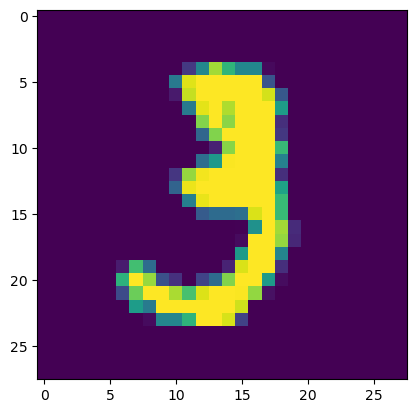

In [5]:
import matplotlib.pyplot as plt
k = 10
plt.imshow(train_data.data[k])
print('Label: ',train_data.targets[k])

In [6]:
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(         
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        #size of x after conv1 is [1, 1, 14, 14] due to maxPool
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )
        #size of x after conv2 is [1, 1, 7, 7] due to maxPool
        
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        
        x = self.conv1(x)
        x = self.conv2(x)
        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x  # return x for visualization
    
cnn = CNN()
print(cnn)


CNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)


In [7]:
from torch.utils.data import DataLoader
loaders = {
    'train' : torch.utils.data.DataLoader(train_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}
print(loaders)

sample = next(iter(loaders['test']))
imgs, lbls = sample
test = cnn(imgs[:1])
print(test[0])

{'train': <torch.utils.data.dataloader.DataLoader object at 0x16a6444d0>, 'test': <torch.utils.data.dataloader.DataLoader object at 0x16a48ca50>}
tensor([[ 0.0026,  0.1192,  0.0475,  0.1074,  0.0217,  0.1439,  0.0717,  0.0220,
          0.0472, -0.0539]], grad_fn=<AddmmBackward0>)


In [8]:
loss_func = nn.CrossEntropyLoss()   
loss_func

CrossEntropyLoss()

In [9]:
from torch import optim
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)   
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)

In [10]:
from torch.autograd import Variable
num_epochs = 10
def train(num_epochs, cnn, loaders):
    
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs): #one epoch = one pass through the dataset
        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)   # batch y
            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()    
            # apply gradients             
            optimizer.step()                
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
                pass
        pass
    
    pass
train(num_epochs, cnn, loaders)

Epoch [1/10], Step [100/600], Loss: 0.2748
Epoch [1/10], Step [200/600], Loss: 0.2027
Epoch [1/10], Step [300/600], Loss: 0.2242
Epoch [1/10], Step [400/600], Loss: 0.1308
Epoch [1/10], Step [500/600], Loss: 0.1979
Epoch [1/10], Step [600/600], Loss: 0.2682
Epoch [2/10], Step [100/600], Loss: 0.1232
Epoch [2/10], Step [200/600], Loss: 0.1901
Epoch [2/10], Step [300/600], Loss: 0.1781
Epoch [2/10], Step [400/600], Loss: 0.1376
Epoch [2/10], Step [500/600], Loss: 0.2237
Epoch [2/10], Step [600/600], Loss: 0.1754
Epoch [3/10], Step [100/600], Loss: 0.0661
Epoch [3/10], Step [200/600], Loss: 0.0717
Epoch [3/10], Step [300/600], Loss: 0.1927
Epoch [3/10], Step [400/600], Loss: 0.1042
Epoch [3/10], Step [500/600], Loss: 0.1936
Epoch [3/10], Step [600/600], Loss: 0.0924
Epoch [4/10], Step [100/600], Loss: 0.2488
Epoch [4/10], Step [200/600], Loss: 0.2279
Epoch [4/10], Step [300/600], Loss: 0.1566
Epoch [4/10], Step [400/600], Loss: 0.2207
Epoch [4/10], Step [500/600], Loss: 0.1622
Epoch [4/10

In [11]:
def test():
    # Test the model
    cnn.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in loaders['test']:
            test_output, last_layer = cnn(images)
            pred_y = torch.max(test_output, 1)[1].data.squeeze()
            correct += (pred_y == labels).sum().item()
            total += float(labels.size(0))
            pass
    return correct, total
    
correct,total = test()

In [12]:
print('Accuracy:', correct/total)

Accuracy: 0.971


In [13]:
sample = next(iter(loaders['test']))
imgs, lbls = sample

actual_number = lbls[:10].numpy()
actual_number

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')

Prediction number: [9 4 5 9 8 0 8 9 1 5]
Actual number: [9 4 5 9 8 0 7 9 1 5]


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import utils

def visTensor(tensor, ch=0, allkernels=False, nrow=8, padding=1): 
    n,c,w,h = tensor.shape

    if allkernels: tensor = tensor.view(n*c, -1, w, h)
    elif c != 3: tensor = tensor[:,ch,:,:].unsqueeze(dim=1)

    rows = np.min((tensor.shape[0] // nrow + 1, 64))    
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, padding=padding)
    plt.figure( figsize=(nrow,rows) )
    plt.imshow(grid.numpy().transpose((1, 2, 0)))



In [15]:
print(cnn.conv1.state_dict()['0.weight'][0])


tensor([[[-0.3732, -0.4078, -1.0860, -1.1162, -0.8277],
         [ 0.4772,  0.2320,  0.4729, -0.3792, -1.2064],
         [ 0.2433,  0.9288,  0.1298,  0.3862, -0.7399],
         [-0.6005, -0.2917, -1.6491, -1.0984, -1.1727],
         [-1.7323, -1.1066, -1.4521,  0.1202, -1.1516]]])


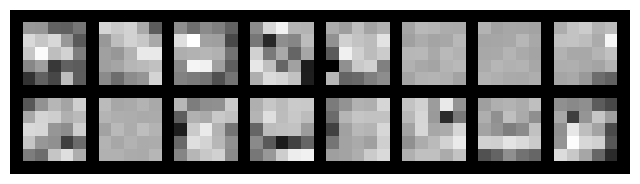

In [21]:
filter = cnn.conv1.state_dict()['0.weight'].clone()
visTensor(filter, ch=0, allkernels=False)

plt.axis('off')
plt.ioff()
plt.show()